In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cpu")

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])


In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)


100%|██████████| 170M/170M [00:04<00:00, 41.9MB/s]


In [6]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        output = self.decoder(latent)
        return output, latent

model = SparseAutoencoder().to(device)




In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
def sparsity_penalty(latent, rho=0.05):

    rho_hat = torch.mean(torch.sigmoid(latent), dim=0)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)


beta = 1e-3

In [9]:
num_epochs = 20

epoch_losses = [] # List to store loss for each epoch

# Check if train_loader is defined
if 'train_loader' not in globals() and 'train_loader' not in locals():
    raise RuntimeError("Error: 'train_loader' is not defined. Please ensure the cells defining the datasets and data loaders (e.g., cell 'a2VzugLHF54c') have been executed before running the training loop.")

for epoch in range(num_epochs):

    total_loss = 0

    for images, _ in train_loader:

        # Flatten images
        images = images.view(images.size(0), -1).to(device)

        outputs, latent = model(images)

        recon_loss = criterion(outputs, images)

        sparse_loss = sparsity_penalty(latent)

        loss = recon_loss + beta * sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_losses.append(total_loss) # Store the total loss for the current epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")

Epoch [1/20], Loss: 13.3459
Epoch [2/20], Loss: 8.6282
Epoch [3/20], Loss: 7.3400
Epoch [4/20], Loss: 6.6138
Epoch [5/20], Loss: 6.2971
Epoch [6/20], Loss: 5.9664
Epoch [7/20], Loss: 5.6785
Epoch [8/20], Loss: 5.4919
Epoch [9/20], Loss: 5.3187
Epoch [10/20], Loss: 5.0983
Epoch [11/20], Loss: 5.0016
Epoch [12/20], Loss: 4.8932
Epoch [13/20], Loss: 4.8307
Epoch [14/20], Loss: 4.6926
Epoch [15/20], Loss: 4.6040
Epoch [16/20], Loss: 4.5624
Epoch [17/20], Loss: 4.5010
Epoch [18/20], Loss: 4.4772
Epoch [19/20], Loss: 4.4249
Epoch [20/20], Loss: 4.3570


In [10]:

model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        outputs, _ = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss)


Test Reconstruction Loss: 0.8846290428191423


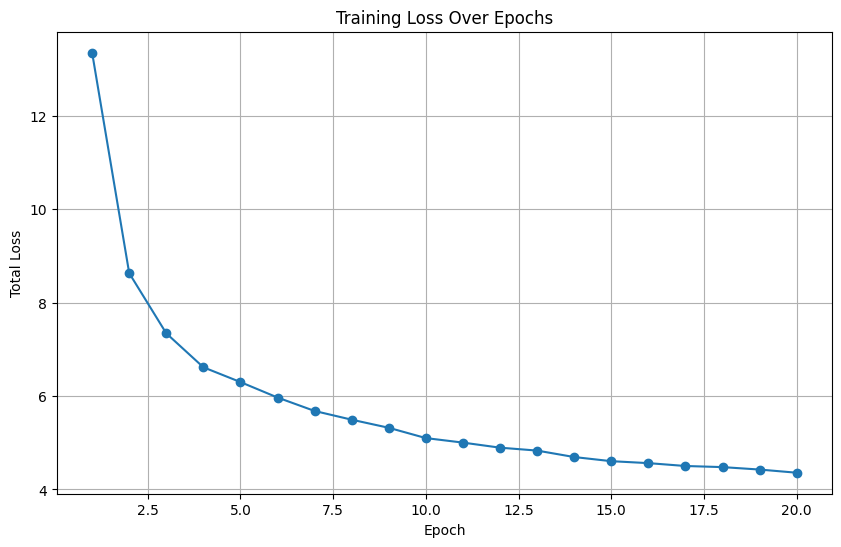

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True)
plt.show()

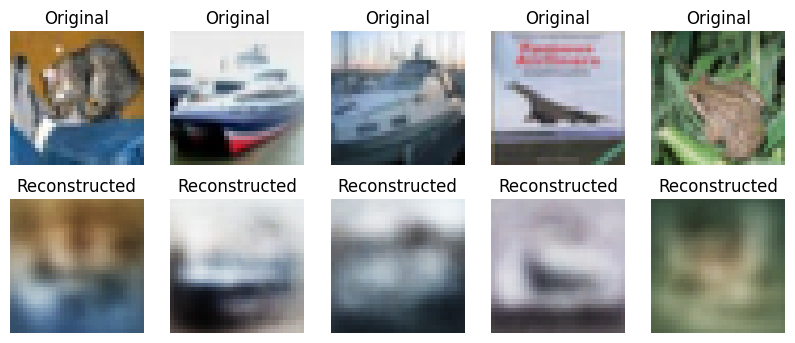

In [11]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

outputs, _ = model(images_flat)

images = images.numpy()
outputs = outputs.view(-1, 3, 32, 32).detach().numpy()

plt.figure(figsize=(10,4))

for i in range(5):

    # Original images
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].transpose(1,2,0))
    plt.title("Original")
    plt.axis("off")

    # Reconstructed images
    plt.subplot(2,5,i+6)
    plt.imshow(outputs[i].transpose(1,2,0))
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

The CIFAR-10 dataset is loaded, which consists of 32x32 color images across 10 classes. The images are transformed into PyTorch tensors.
DataLoaders are created for efficient batch processing during training and testing.


Encoder: This part compresses the 3072-pixel (3x32x32) input images into a smaller 64-dimensional latent representation. It uses linear layers and ReLU activation functions.

Decoder: This part attempts to reconstruct the original 3072-pixel image from the 64-dimensional latent representation. It also uses linear layers, ReLU, and a final Sigmoid activation to ensure pixel values are between 0 and 1.

In each epoch, the model iterates through the train_loader, flattens the images, performs a forward pass to get reconstructions and latent codes.

A plot is generated to visualize how the total_loss decreased over the 20 epochs, indicating that the model learned to reconstruct images and maintain sparsity.

When the decoder tries to reconstruct the image from this highly compressed representation, some fine details are inevitably lost, leading to a smoother, blurrier output.